In [1]:
# ! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf

In [2]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
import os

load_dotenv()

# LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

# Embeddings
embeddings = HuggingFaceBgeEmbeddings(
    model_name="BAAI/bge-small-en-v1.5",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

C:\Users\harsh\AppData\Local\Temp\ipykernel_40032\1216882458.py:24: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceBgeEmbeddings(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
loader = PyPDFLoader('intro-to-ml.pdf')
docs= loader.load()

In [4]:
len(docs)

392

In [5]:

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [6]:
len(chunks)

973

In [10]:
vector_store =FAISS.from_documents(chunks , embeddings)
vector_store

In [11]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [12]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    If there is no answer then just simply say that you dont know ,don't hallucinate    
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [13]:
tools = [rag_tool]
llm_with_tool = llm.bind_tools(tools)

In [14]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage] , add_messages]

In [15]:
def chat_node(state:ChatState):
    messages = state['messages']
    response = llm_with_tool.invoke(messages)
    return {'messages':[response]}

In [16]:
tool_node = ToolNode(tools)

In [17]:
graph = StateGraph(ChatState)

graph.add_node('chat_node' , chat_node)
graph.add_node('tools' ,tool_node)

graph.add_edge(START , 'chat_node')
graph.add_conditional_edges('chat_node' , tools_condition)
graph.add_edge('tools' , 'chat_node')


In [18]:
chatbot = graph.compile()

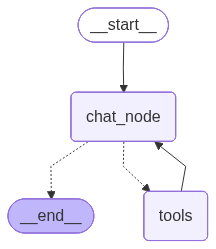

In [19]:
chatbot

In [20]:
chatbot.invoke({
    'messages':[HumanMessage(content = ('What is machine Learning'))]}
)

{'messages': [HumanMessage(content='What is machine Learning', additional_kwargs={}, response_metadata={}, id='5814ff27-148e-4fd4-9dac-15b49805eeda'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '06ze4sdfg', 'function': {'arguments': '{"query":"definition of machine learning"}', 'name': 'rag_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 298, 'total_tokens': 316, 'completion_time': 0.050736896, 'completion_tokens_details': None, 'prompt_time': 0.020872985, 'prompt_tokens_details': None, 'queue_time': 0.167082785, 'total_time': 0.071609881}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d5d1c-9c86-7b80-881f-fccfd8583681-0', tool_calls=[{'name': 'rag_tool', 'args': {'query': 'definition of machine learning'}, 'id': '06ze4sdfg', 'type': 'tool_call'}], inval